## Q2. Symmetric proposal distributions

In [285]:
import random
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from scipy.integrate import quad

## Defined functions

In [262]:
# Target function
def target_fn(x, z):
    return np.exp(-x**4)/z

# Symmetric Proposal Functions
def uniform_proposal(x, step_size=0.01):
    """Uniform distribution to generate new step size
    Params:
        x (float): current position of x
        step_size (float): bounds of uniform func

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + np.random.uniform(-step_size, step_size)
    return updated_x

def rw_proposal(x, step_size=0.01):
    """Uniform distribution to choose left and right direction and take the predefined step
    Params:
        x (float): current position of x
        step_size (float): size of each step

    Returns:
        updated_x (float): next position of x
    """
    decider = np.random.uniform(0, 1)
    if decider > 0.5:
        updated_x = x + step_size
    else:
        updated_x = x - step_size
    return updated_x

def normal_proposal(x, sigma=1):
    """
    N(x, sigma^2) distribution to generate new step size
    Params:
        x (float): current position of x
        sigma (float): standard deviation

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + np.random.normal(0, sigma)
    return updated_x

In [263]:
# Metropolis sampler with symmetric proposal function
def universal_metropolis_sampler(dist, num_samples, initial_x, z,
                                 step_size=None, sigma=None, df=None):
    """Metropolis sampler for all symmetric proposal functions
    Params:
        dist: symmetric proposal distributions (uniform, rw, normal, student)
        num_samples (int): number of samples for simulation
        initial_x (float): initial position of x

    Returns:
        samples (np.array): arrays of generated samples
    """
    lst = {"uniform": uniform_proposal,
           "rw": rw_proposal,
           "normal": normal_proposal,
           }

    samples = [initial_x]
    x = initial_x
    accepted = 0 # counter for accepted proposals

    for _ in range(num_samples - 1):
        sampler = lst[dist]
        # Call the function with parameter
        if dist in ["uniform", "rw"]:
            x_proposal = sampler(x, step_size)
        elif dist == "normal":
            x_proposal = sampler(x, sigma)
        elif dist == "student":
            x_proposal = sampler(x, df)
        else:
            raise ValueError(f"{dist} distribution is unavailable.")

        # Metropolis acceptance step
        acceptance_ratio = target_fn(x_proposal, z) / target_fn(x, z)
        if np.random.rand() < min(1, acceptance_ratio):
            x = x_proposal
            accepted += 1

        samples.append(x)

    acceptance_rate = accepted / (num_samples - 1)
    # Message
    print(f"Acceptance rate: {acceptance_rate:.4f}")

    return np.array(samples), acceptance_rate

## 2a. Estimate the normalization factor Z

In [264]:
Z = quad(lambda x: np.exp(-x**4), -np.inf, np.inf)[0]
print("Estimated normalization factor Z =", Z)

Estimated normalization factor Z = 1.8128049541109543


In [265]:
# Generate samples and number of bins
N1, N2, N3 = 50, 500, 5000
B1, B2, B3 = 30, 30, 30
INITIAL_X = 0.0
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

## 2b

In [266]:
# Generate samples and number of bins
N = 1000
B1, B2, B3 = 30, 30, 30
UNIFORM_STEP = 1
RW_STEP = 0.5
SIGMA = 1
INITIAL_X = 0.0
metropolis_results = {}
# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=UNIFORM_STEP)
samples_rw, acc_rw = universal_metropolis_sampler(dist="rw", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=RW_STEP)
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=SIGMA)

# Save results
metropolis_results["Uniform"] = {"samples": samples_uniform, "acceptance_rate": acc_uniform}
metropolis_results["Random Walk"] = {"samples": samples_rw, "acceptance_rate": acc_rw}
metropolis_results["Normal"] = {"samples": samples_normal, "acceptance_rate": acc_normal}

Acceptance rate: 0.6867
Acceptance rate: 0.6947
Acceptance rate: 0.6086


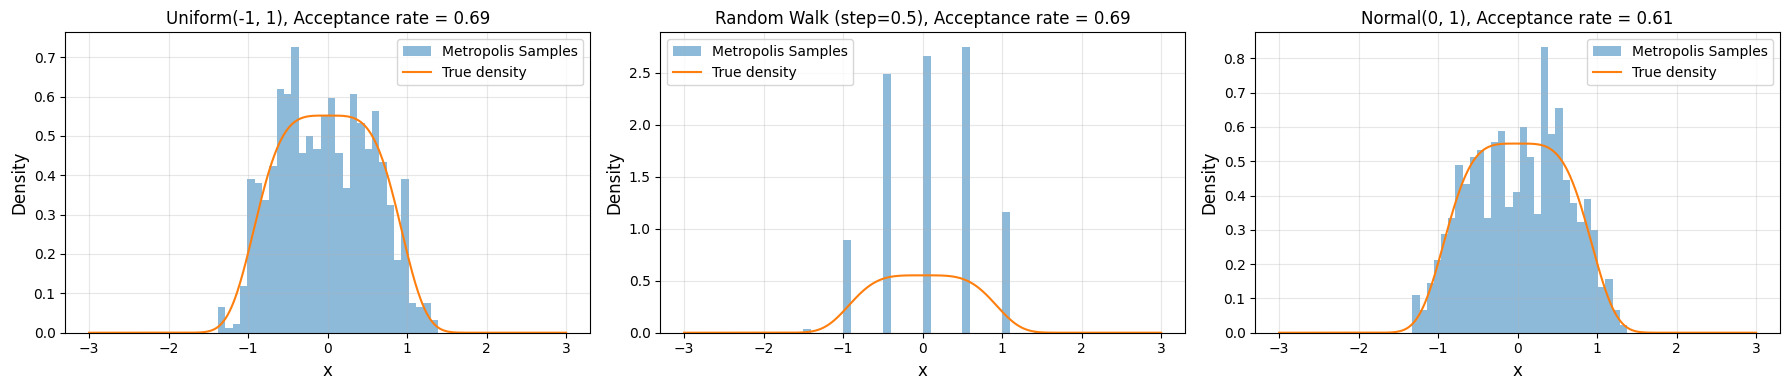

In [267]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
# First pic
ax[0].hist(samples_uniform, bins=B1, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[0].plot(x_vals, true_density, label="True density")
ax[0].set_title(f"Uniform(-{UNIFORM_STEP}, {UNIFORM_STEP}), Acceptance rate = {acc_rw:.2f}")
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('Density', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='upper right')

# Second pic
ax[1].hist(samples_rw, bins=B2, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[1].plot(x_vals, true_density, label="True density")
ax[1].set_title(f"Random Walk (step={RW_STEP}), Acceptance rate = {acc_rw:.2f}")
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('Density', fontsize=12)
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc='upper left')

# Third pic
ax[2].hist(samples_normal, bins=B3, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[2].plot(x_vals, true_density, label="True density")
ax[2].set_title(f"Normal(0, {SIGMA}), Acceptance rate = {acc_normal:.2f}")
ax[2].set_xlabel('x', fontsize=12)
ax[2].set_ylabel('Density', fontsize=12)
ax[2].grid(True, alpha=0.3)
ax[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Trace plots

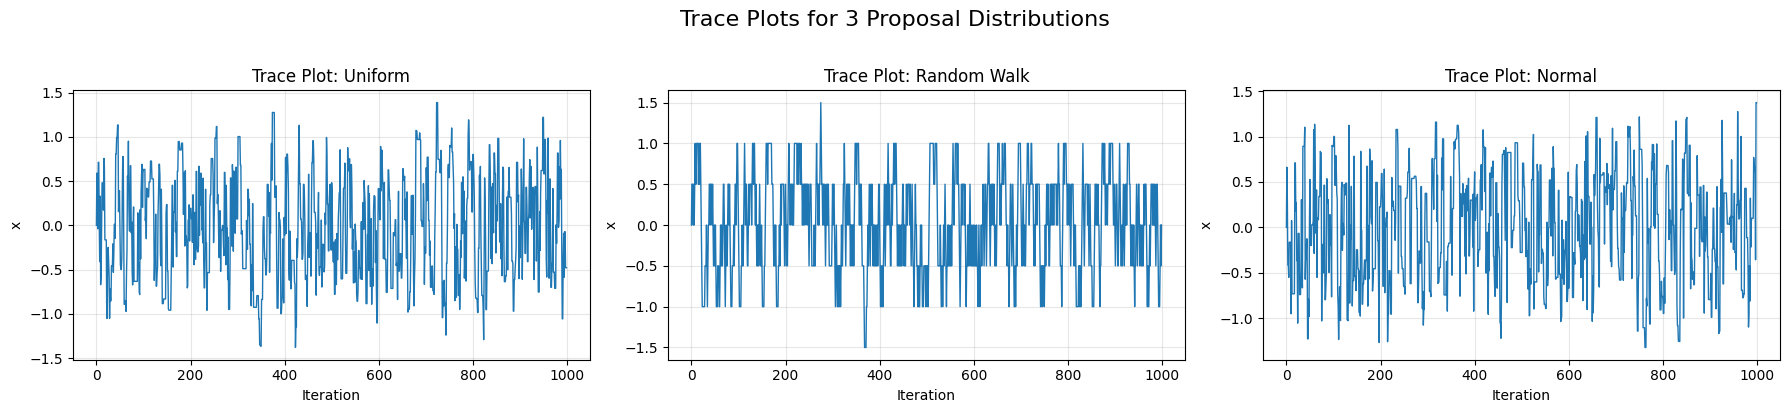

In [268]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]

    ax.plot(samples, linewidth=1)

    ax.set_title(f"Trace Plot: {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("x")
    ax.grid(True, alpha=0.3)

plt.suptitle("Trace Plots for 3 Proposal Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Running mean convergence
Since f(x) is symmetric around 0, the true mean is 0. The running mean should move toward 0 if sampling works well.

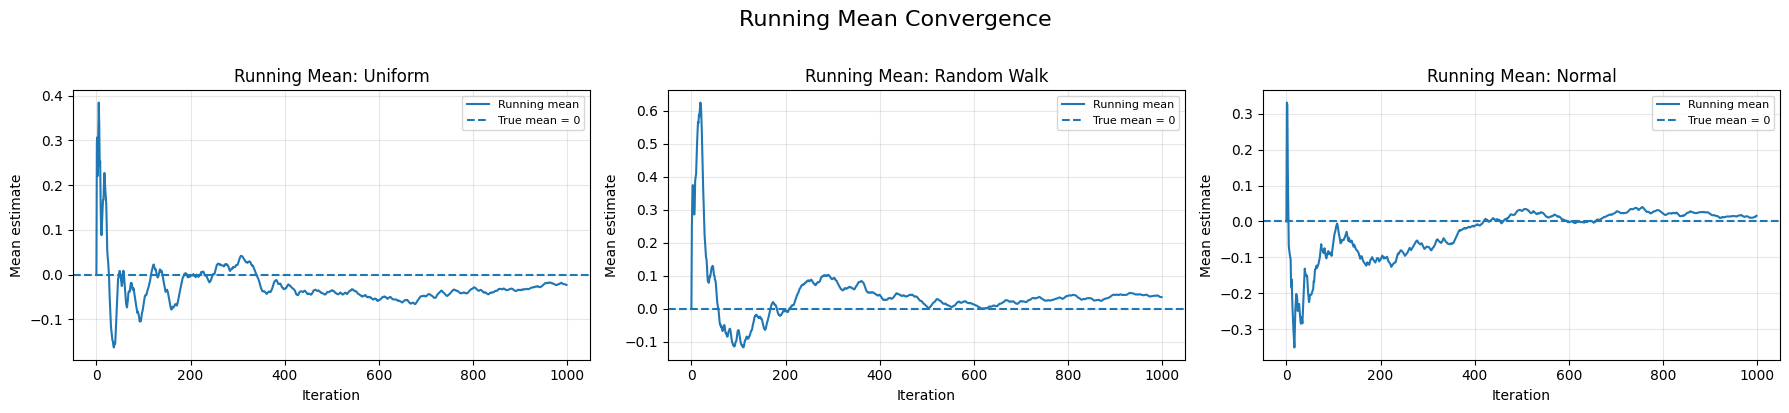

In [269]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    running_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)

    ax.plot(running_mean, linewidth=1.5, label="Running mean")
    ax.axhline(0, linestyle="--", linewidth=1.5, label="True mean = 0")

    ax.set_title(f"Running Mean: {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean estimate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Running Mean Convergence", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Step 11: Autocorrelation function
Lower autocorrelation usually means better mixing. If autocorrelation stays high, samples are strongly dependent.

In [280]:
def autocorrelation(samples, max_lag=50):
    """
    Compute autocorrelation values up to max_lag.
    """

    samples = np.asarray(samples)
    samples_centered = samples - np.mean(samples)

    acf_values = []

    for lag in range(max_lag + 1):

        if lag == 0:
            acf_values.append(1.0)
        else:
            corr = np.corrcoef(
                samples_centered[:-lag],
                samples_centered[lag:]
            )[0, 1]
            acf_values.append(corr)

    return np.array(acf_values)

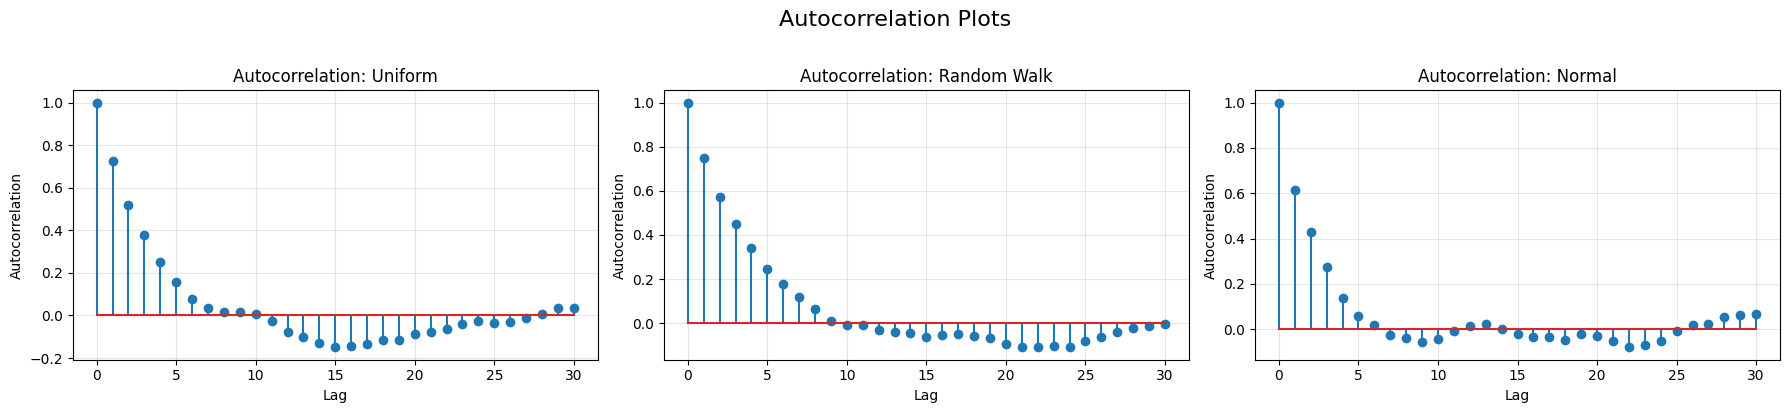

In [284]:
max_lag = 30

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    acf_values = autocorrelation(samples, max_lag=max_lag)

    markerline, stemlines, baseline = ax.stem(
        range(max_lag + 1),
        acf_values
    )

    ax.set_title(f"Autocorrelation: {proposal_name}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.grid(True, alpha=0.3)

plt.suptitle("Autocorrelation Plots", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Numerical performance table

In [286]:
performance_rows = []

# Theoretical moment values
true_mean = 0.0
true_fourth_moment = 1 / 4

for proposal_name, result in metropolis_results.items():

    samples = result["samples"]
    acceptance_rate = result["acceptance_rate"]

    sample_mean = np.mean(samples)
    sample_variance = np.var(samples)
    sample_fourth_moment = np.mean(samples**4)

    mean_abs_error = abs(sample_mean - true_mean)
    fourth_moment_abs_error = abs(sample_fourth_moment - true_fourth_moment)

    performance_rows.append({
        "Proposal": proposal_name,
        "Acceptance Rate": acceptance_rate,
        "Sample Mean": sample_mean,
        "Mean Absolute Error": mean_abs_error,
        "Sample Variance": sample_variance,
        "Sample E[X^4]": sample_fourth_moment,
        "True E[X^4]": true_fourth_moment,
        "E[X^4] Absolute Error": fourth_moment_abs_error,
    })

performance_table = pd.DataFrame(performance_rows)

performance_table

,Proposal,Acceptance Rate,Sample Mean,Mean Absolute Error,Sample Variance,Sample E[X^4],True E[X^4],E[X^4] Absolute Error
0,Uniform,0.686687,-0.022816,0.022816,0.342432,0.246414,0.25,0.003586
1,Random Walk,0.694695,0.035500,0.035500,0.345990,0.263062,0.25,0.013062
2,Normal,0.608609,0.015593,0.015593,0.363597,0.276375,0.25,0.026375


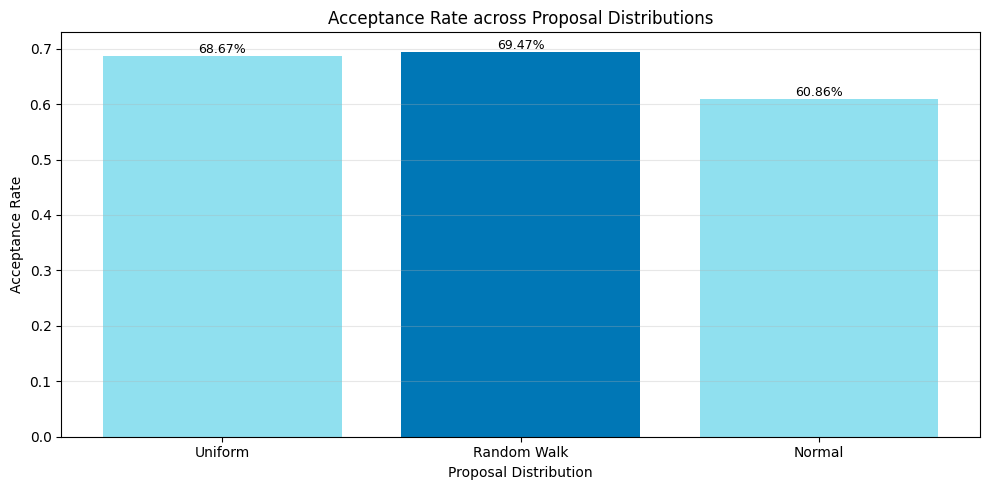

In [294]:
# Acceptance Rate Comparison
LIGHT_BLUE = "#90e0ef"
DARK_BLUE  = "#0077b6"

max_idx = performance_table["Acceptance Rate"].idxmax()
colors = [
    DARK_BLUE if i == max_idx else LIGHT_BLUE
    for i in performance_table.index
]

plt.figure(figsize=(10, 5))
plt.bar(performance_table["Proposal"],
      performance_table["Acceptance Rate"],
      color=colors,
)

plt.title("Acceptance Rate across Proposal Distributions")
plt.xlabel("Proposal Distribution")
plt.ylabel("Acceptance Rate")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(performance_table["Acceptance Rate"]):
    plt.text(i, value, f"{value:.2%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Extra visualization

In [270]:
# Generate samples and number of bins
N1, N2, N3 = 50, 500, 5000
B1, B2, B3 = 30, 30, 30
INITIAL_X = 0.0

# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

### Uniform distribution

In [271]:
STEP = 1
samples_uniform1, acc_uniform1 = universal_metropolis_sampler(dist="uniform", num_samples=N1, z=Z,
                                                              initial_x=INITIAL_X, step_size=STEP)
samples_uniform2, acc_uniform2 = universal_metropolis_sampler(dist="uniform", num_samples=N2, z=Z,
                                                              initial_x=INITIAL_X, step_size=STEP)
samples_uniform3, acc_uniform3 = universal_metropolis_sampler(dist="uniform", num_samples=N3, z=Z,
                                                              initial_x=INITIAL_X, step_size=STEP)

Acceptance rate: 0.7755
Acceptance rate: 0.7034
Acceptance rate: 0.7237


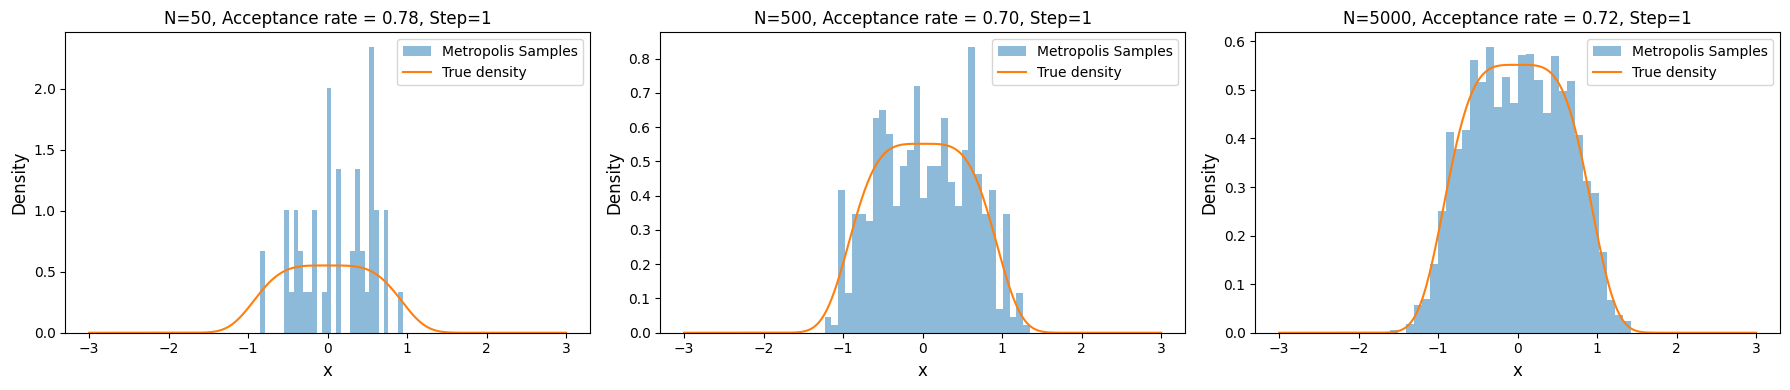

In [272]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
# First pic
ax[0].hist(samples_uniform1, bins=B1, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[0].plot(x_vals, true_density, label="True density")
ax[0].set_title(f"N={N1}, Acceptance rate = {acc_uniform1:.2f}, Step={STEP}")
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('Density', fontsize=12)
ax[0].legend(loc='upper right')

# Second pic
ax[1].hist(samples_uniform2, bins=B2, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[1].plot(x_vals, true_density, label="True density")
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('Density', fontsize=12)
ax[1].set_title(f"N={N2}, Acceptance rate = {acc_uniform2:.2f}, Step={STEP}")
ax[1].legend(loc='upper right')

# Third pic
ax[2].hist(samples_uniform3, bins=B3, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[2].plot(x_vals, true_density, label="True density")
ax[2].set_xlabel('x', fontsize=12)
ax[2].set_ylabel('Density', fontsize=12)
ax[2].set_title(f"N={N3}, Acceptance rate = {acc_uniform3:.2f}, Step={STEP}")
ax[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Random walk

In [273]:
# Generate samples
STEP = 0.01
samples_rw1, acc_rw1 = universal_metropolis_sampler(dist="rw", num_samples=N1, z=Z,
                                                    initial_x=INITIAL_X, step_size=STEP)
samples_rw2, acc_rw2 = universal_metropolis_sampler(dist="rw", num_samples=N2, z=Z,
                                                    initial_x=INITIAL_X, step_size=STEP)
samples_rw3, acc_rw3 = universal_metropolis_sampler(dist="rw", num_samples=N3, z=Z,
                                                    initial_x=INITIAL_X, step_size=STEP)

Acceptance rate: 1.0000
Acceptance rate: 1.0000
Acceptance rate: 0.9990


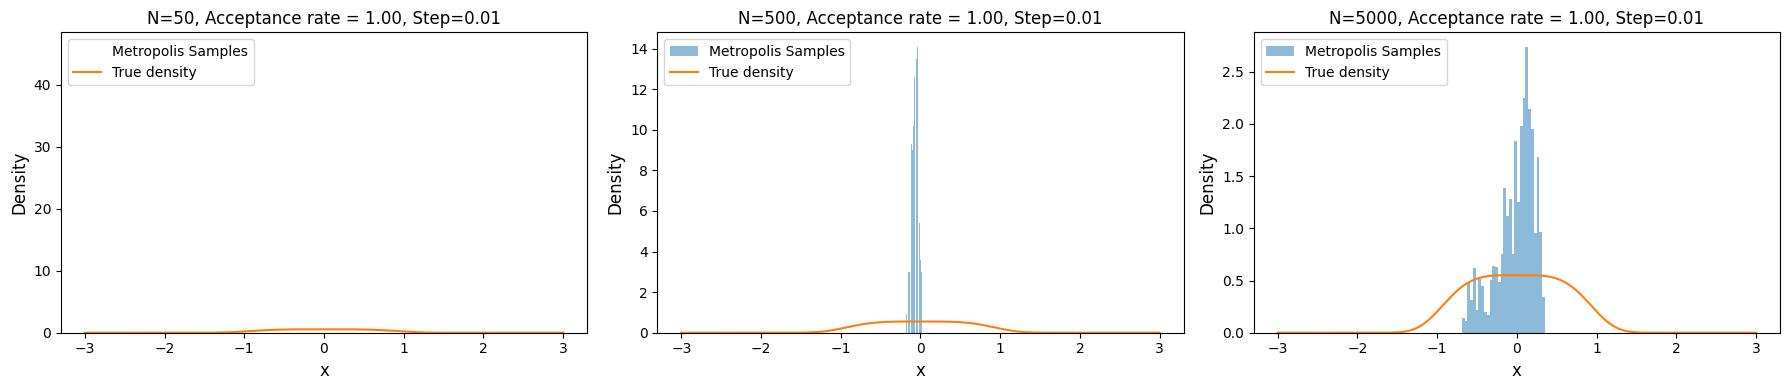

In [274]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
# First pic
ax[0].hist(samples_rw1, bins=B1, density=True, alpha=0, label=f"Metropolis Samples")
ax[0].plot(x_vals, true_density, label="True density")
ax[0].set_title(f"N={N1}, Acceptance rate = {acc_rw1:.2f}, Step={STEP}")
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('Density', fontsize=12)
ax[0].legend(loc='upper left')

# Second pic
ax[1].hist(samples_rw2, bins=B2, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[1].plot(x_vals, true_density, label="True density")
ax[1].set_title(f"N={N2}, Acceptance rate = {acc_rw2:.2f}, Step={STEP}")
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('Density', fontsize=12)
ax[1].legend(loc='upper left')

# Third pic
ax[2].hist(samples_rw3, bins=B3, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[2].plot(x_vals, true_density, label="True density")
ax[2].set_title(f"N={N3}, Acceptance rate = {acc_rw3:.2f}, Step={STEP}")
ax[2].set_xlabel('x', fontsize=12)
ax[2].set_ylabel('Density', fontsize=12)
ax[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Normal distribution

In [275]:
# Generate samples
SIGMA = 1
samples_normal1, acc_normal1 = universal_metropolis_sampler(dist="normal", num_samples=N1, z=Z,
                                                    initial_x=INITIAL_X, sigma=SIGMA)
samples_normal2, acc_normal2 = universal_metropolis_sampler(dist="normal", num_samples=N2, z=Z,
                                                    initial_x=INITIAL_X, sigma=SIGMA)
samples_normal3, acc_normal3 = universal_metropolis_sampler(dist="normal", num_samples=N3, z=Z,
                                                    initial_x=INITIAL_X, sigma=SIGMA)

Acceptance rate: 0.6122
Acceptance rate: 0.6052
Acceptance rate: 0.5953


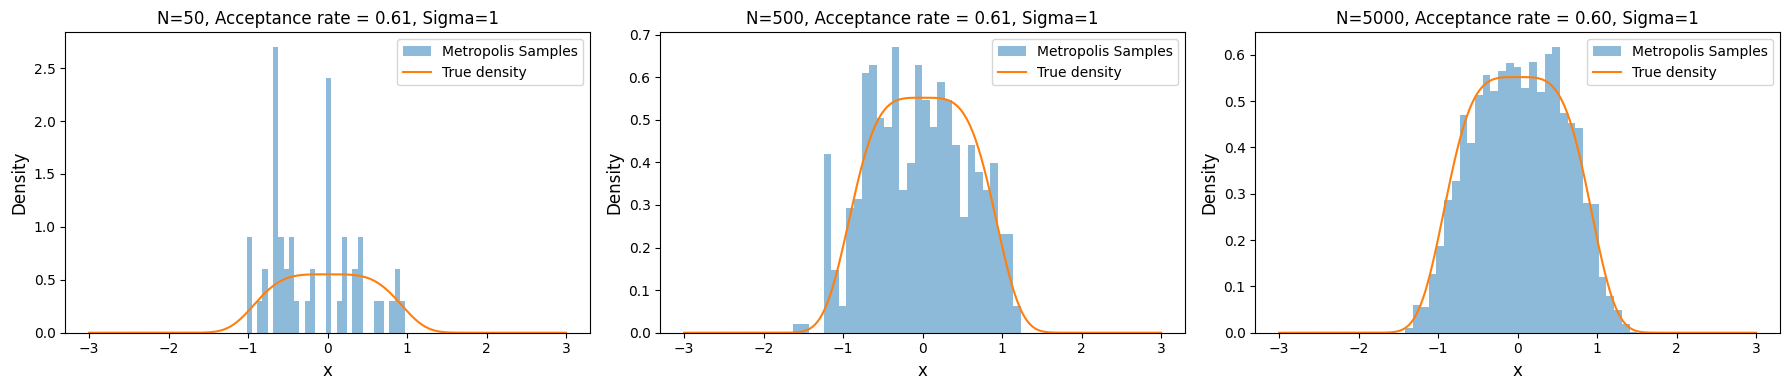

In [276]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
# First pic
ax[0].hist(samples_normal1, bins=B1, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[0].plot(x_vals, true_density, label="True density")
ax[0].set_title(f"N={N1}, Acceptance rate = {acc_normal1:.2f}, Sigma={SIGMA}")
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('Density', fontsize=12)
ax[0].legend(loc='upper right')

# Second pic
ax[1].hist(samples_normal2, bins=B2, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[1].plot(x_vals, true_density, label="True density")
ax[1].set_title(f"N={N2}, Acceptance rate = {acc_normal2:.2f}, Sigma={SIGMA}")
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('Density', fontsize=12)
ax[1].legend(loc='upper right')

# Third pic
ax[2].hist(samples_normal3, bins=B3, density=True, alpha=0.5, label=f"Metropolis Samples")
ax[2].plot(x_vals, true_density, label="True density")
ax[2].set_title(f"N={N3}, Acceptance rate = {acc_normal3:.2f}, Sigma={SIGMA}")
ax[2].set_xlabel('x', fontsize=12)
ax[2].set_ylabel('Density', fontsize=12)
ax[2].legend(loc='upper right')

plt.tight_layout()
plt.show()